# 58. Trigonometric Interpolation and the DFT

**Part 8: Approximation Theory and Transforms**

## Learning objectives

By the end of this lesson you will be able to:

1. Use the three facts about **roots of unity** that everything in this lesson rests on.
2. Write the DFT and its inverse, and say what each index means.
3. Prove that the transform matrix is **orthogonal**, and see that its condition number is
   exactly 1.
4. State and check the **DFT interpolation theorem**, and get the frequency convention right.
5. Recognise **aliasing** and the Nyquist limit, and say what is lost rather than approximated.
6. Use the shift and convolution theorems, and see why the second one makes lesson 59 matter.
7. Generate the twiddle factors by a recurrence that does not drift.

## Prerequisites

Lesson 55 (orthogonal bases, and why one makes the fit trivial). Lesson 44 (the Vandermonde
matrix, which this lesson's matrix is a special case of). Lesson 46 (interpolation error, whose
periodic analogue is aliasing). Complex arithmetic.

---

## 1. Orthogonality for free

Lesson 55 fixed lesson 54's conditioning problem by choosing an orthogonal basis, at the cost of
computing inner products. **On equally spaced points, the trigonometric basis is orthogonal
exactly, and the inner products are finite sums the grid hands you.**

That is the whole reason the DFT is everywhere: no integrals, no quadrature, no linear system,
and a condition number of 1.

Let $w = e^{-2\pi i/n}$. Three facts about its powers carry the lesson.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import dft as dt

for n in (4, 5, 8, 16):
    out = dt.root_properties(n)
    half = out["half_turn_is_minus_one"]
    print(f"n = {n:>3}: sum {abs(out['sum']):.2e}, "
          f"all on the unit circle to {out['on_the_unit_circle']:.1e}, "
          f"wraps at n to {out['wraps_at_n']:.1e}, "
          f"w^(n/2) = {'-1' if half is not None and abs(half + 1) < 1e-12 else 'no half turn'}")
    assert out["sum_is_zero"] and out["wraps_at_n"] < 1e-12

n =   4: sum 2.48e-16, all on the unit circle to 0.0e+00, wraps at n to 2.4e-16, w^(n/2) = -1
n =   5: sum 2.48e-16, all on the unit circle to 1.1e-16, wraps at n to 3.1e-16, w^(n/2) = no half turn
n =   8: sum 3.66e-16, all on the unit circle to 2.2e-16, wraps at n to 1.1e-15, w^(n/2) = -1
n =  16: sum 9.32e-16, all on the unit circle to 2.2e-16, wraps at n to 1.1e-15, w^(n/2) = -1


- **They sum to zero** for $n > 1$, because they are the roots of $z^n - 1$, which has no
  $z^{n-1}$ term. This is what makes the orthogonality work.
- **Exponents live mod $n$**, so $w^j$ and $w^{j+n}$ are the same point. This is aliasing.
- **$w^{n/2} = -1$** for even $n$. This is what lesson 59's fast algorithm is built on.

## 2. The transform

$$
X_k = \sum_{j=0}^{n-1}x_j\,w^{jk}, \qquad x_j = \frac1n\sum_{k=0}^{n-1}X_k\,w^{-jk}
$$

Only the sign and the $1/n$ differ. Both are $O(n^2)$ as written, which lesson 59 fixes without
changing what is computed.

In [3]:
gen = np.random.default_rng(42)
print(f"{'n':>5}{'vs numpy':>14}{'round trip':>14}")
for n in (1, 2, 3, 7, 16, 33, 64):
    x = gen.standard_normal(n)
    ref = np.fft.fft(x)
    gap = float(np.max(np.abs(dt.dft(x) - ref))) / max(float(np.max(np.abs(ref))), 1.0)
    print(f"{n:>5}{gap:>14.2e}{dt.round_trip(x):>14.2e}")
    assert gap < 1e-12 and dt.round_trip(x) < 1e-12

    n      vs numpy    round trip
    1      0.00e+00      0.00e+00
    2      5.13e-17      6.12e-17
    3      3.78e-16      2.40e-16
    7      2.34e-15      6.67e-16
   16      1.78e-15      2.12e-15
   33      5.72e-15      5.63e-15
   64      9.86e-15      9.04e-15


Reading a spectrum means reading bin $k$ as "frequency $k$ cycles per block":

In [4]:
n = 16
j = np.arange(n)
for k in (0, 1, 3, 5):
    X = dt.dft(np.exp(2j * np.pi * k * j / n))
    peak = int(np.argmax(np.abs(X)))
    print(f"a pure tone at {k} cycles per block puts all its energy in bin {peak}, "
          f"height {abs(X[peak]):.4f}, everything else below "
          f"{float(np.max(np.abs(np.delete(X, peak)))):.1e}")
    assert peak == k

a pure tone at 0 cycles per block puts all its energy in bin 0, height 16.0000, everything else below 1.7e-14
a pure tone at 1 cycles per block puts all its energy in bin 1, height 16.0000, everything else below 1.0e-14
a pure tone at 3 cycles per block puts all its energy in bin 3, height 16.0000, everything else below 1.9e-14
a pure tone at 5 cycles per block puts all its energy in bin 5, height 16.0000, everything else below 1.3e-14


## 3. Why it is so well behaved

**Theorem.** $F^HF = nI$, where $F_{jk} = w^{jk}$.

**Proof.** The $(j,\ell)$ entry of $F^HF$ is $\sum_k w^{-jk}w^{\ell k} = \sum_k(w^{\ell-j})^k$, a
geometric series with ratio $w^{\ell-j}$. When $\ell = j$ the ratio is 1 and the sum is $n$.
Otherwise the ratio is an $n$th root of unity other than 1, and the series sums to
$(w^{(\ell-j)n}-1)/(w^{\ell-j}-1) = 0$ because $w^n = 1$.

So the columns are orthogonal with squared norm $n$, $F/\sqrt n$ is unitary, and:

In [5]:
print(f"{'n':>6}{'DFT kappa':>13}{'Vandermonde kappa':>21}")
out = dt.conditioning((4, 8, 16, 20, 32, 64))
for n, d, v in zip(out["sizes"], out["dft_condition"], out["vandermonde_condition"]):
    print(f"{n:>6}{d:>13.6f}{v:>21.4e}")
    assert abs(d - 1.0) < 1e-9

     n    DFT kappa    Vandermonde kappa
     4     1.000000           1.6343e+02
     8     1.000000           4.5005e+05
    16     1.000000           5.3446e+12
    20     1.000000           1.9496e+16
    32     1.000000           4.5887e+18
    64     1.000000           1.9991e+20


**Both matrices are interpolation matrices on $n$ nodes.** One has condition number 1 at every
size and the other passes $10^{16}$ by 20 nodes. Nothing else in this course has a condition
number of exactly 1.

Energy is preserved, which follows immediately:

In [6]:
for n in (8, 16, 64):
    out = dt.parseval(gen.standard_normal(n))
    print(f"n = {n:>3}: time energy {out['time_energy']:.6f}, "
          f"frequency energy {out['frequency_energy']:.6f}, "
          f"relative gap {out['relative_gap']:.1e}")
    assert out["relative_gap"] < 1e-12

n =   8: time energy 7.322254, frequency energy 7.322254, relative gap 2.4e-16
n =  16: time energy 24.630017, frequency energy 24.630017, relative gap 4.3e-16
n =  64: time energy 58.104887, frequency energy 58.104887, relative gap 2.4e-16


## 4. The interpolation theorem

This is what makes the DFT an interpolation method rather than a change of basis.

**Theorem.** For $t_j = j/n$ on $[0,1)$, the function

$$
P(t) = \frac1n\sum_{k=0}^{n-1}X_k\,e^{2\pi ikt}
$$

satisfies $P(t_j) = x_j$ exactly, for every $j$, for any data. So the DFT coefficients **are** the
coefficients of the interpolating trigonometric polynomial, and no system was solved.

In [7]:
print(f"{'n':>5}{'uncentred':>13}{'centred':>13}{'both':>8}")
for n in (4, 5, 16, 17, 64):
    out = dt.interpolation_theorem(gen.standard_normal(n))
    print(f"{n:>5}{out['naive_gap']:>13.2e}{out['centred_gap']:>13.2e}"
          f"{str(out['both_interpolate']):>8}")
    assert out["both_interpolate"]

    n    uncentred      centred    both
    4     1.67e-16     2.88e-16    True
    5     3.27e-16     2.48e-16    True
   16     1.49e-15     1.78e-15    True
   17     2.66e-15     2.21e-15    True
   64     5.45e-15     6.28e-15    True


**Both conventions interpolate, and only one of them is a sensible curve.** At the grid points,
frequency $k$ and frequency $k-n$ are indistinguishable, so the sum can be written with
frequencies $0,\dots,n-1$ or with $-n/2,\dots,n/2-1$. **Between** the grid points they are wildly
different: the first treats a frequency of $n-1$ as a very fast oscillation instead of a slow one
going backwards.

In [8]:
f = lambda t: np.sin(2.0 * np.pi * 3.0 * t) + 0.5 * np.cos(2.0 * np.pi * t)
print(f"{'n':>5}{'uncentred error':>18}{'centred error':>16}"
      f"{'uncentred imaginary':>21}{'centred imaginary':>19}")
for n in (8, 16, 32, 64):
    out = dt.naive_versus_centred(f, n)
    print(f"{n:>5}{out['naive_error']:>18.4f}{out['centred_error']:>16.2e}"
          f"{out['naive_max_imaginary']:>21.4f}{out['centred_max_imaginary']:>19.2e}")
    assert out["centred_error"] < 1e-10
    assert out["naive_error"] > 0.1

    n   uncentred error   centred error  uncentred imaginary  centred imaginary
    8            1.3865        3.83e-15               1.3865           1.49e-15
   16            1.4273        4.05e-15               1.4274           2.28e-15
   32            1.4402        7.51e-15               1.4400           5.30e-15
   64            1.4437        1.30e-14               1.4431           1.02e-14


The uncentred version is off by **1.43** on a function bounded by 1.5, and it is complex, with an
imaginary part of the same size. That is not a rounding artefact. For a real signal of even length
the Nyquist coefficient has to be split in half between $+n/2$ and $-n/2$, and doing so is what
makes the interpolant real.

For real data, half the spectrum is redundant:

In [9]:
for n in (8, 9, 16, 17):
    out = dt.hermitian_symmetry(gen.standard_normal(n))
    print(f"n = {n:>3}: X[n-k] = conj(X[k]) to {out['relative']:.1e}, "
          f"{out['independent_values']} independent values out of {n}")
    assert out["holds"]

n =   8: X[n-k] = conj(X[k]) to 1.5e-15, 5 independent values out of 8
n =   9: X[n-k] = conj(X[k]) to 2.6e-15, 5 independent values out of 9
n =  16: X[n-k] = conj(X[k]) to 2.7e-15, 9 independent values out of 16
n =  17: X[n-k] = conj(X[k]) to 4.9e-15, 9 independent values out of 17


That is why a real FFT of length $n$ returns $n/2+1$ numbers, and lesson 60 uses it.

## 5. Aliasing

$e^{2\pi ikt}$ and $e^{2\pi i(k+n)t}$ agree at **every** grid point, because they differ by
$e^{2\pi ij}$, which is 1. So the grid cannot distinguish them, and there is no way to recover
which one was sampled.

In [10]:
n = 8
out = dt.aliasing(n, [1, 1 + n, 1 + 2 * n, 1 + 5 * n])
print(f"a grid of {n} points, and the frequencies it confuses:")
print(f"{'frequency':>12}{'folds to':>11}{'gap on the grid':>18}{'gap off it':>13}")
for k, fold, on, off in zip(out["frequencies"], out["folded_to"],
                            out["gap_on_the_grid"], out["gap_off_the_grid"]):
    print(f"{k:>12}{fold:>11}{on:>18.1e}{off:>13.4f}")
assert np.all(out["gap_on_the_grid"] < 1e-12)
assert np.all(out["gap_off_the_grid"][1:] > 0.5)

a grid of 8 points, and the frequencies it confuses:
   frequency   folds to   gap on the grid   gap off it
           1          1           0.0e+00       0.0000
           9          1           3.2e-15       2.0000
          17          1           9.5e-15       2.0000
          41          1           3.8e-14       2.0000


**This is worse than lesson 46's interpolation error.** There, the value between the nodes was
approximated and the error was bounded. Here, the information is **absent**: two different
functions produce identical data, so no method whatever can tell them apart.

The threshold has a name:

In [11]:
tone = lambda t, freq: np.sin(2.0 * np.pi * freq * t)
for f_true in (3.0, 7.0):
    out = dt.nyquist(tone, f_true, sizes=(4, 8, 16, 32, 64))
    print(f"\na tone at {f_true:.0f} cycles, sampled at several rates:")
    print(f"{'samples':>9}{'Nyquist limit':>15}{'reconstruction error':>23}"
          f"{'reported bin':>14}{'aliased':>9}")
    for n, lim, err, fold, above in zip(out["sizes"], out["nyquist_limit"],
                                        out["reconstruction_error"],
                                        out["folded_frequency"], out["above_nyquist"]):
        print(f"{n:>9}{lim:>15.1f}{err:>23.2e}{fold:>14}{str(above):>9}")


a tone at 3 cycles, sampled at several rates:
  samples  Nyquist limit   reconstruction error  reported bin  aliased
        4            2.0               1.54e+00             1     True
        8            4.0               4.05e-15             3    False
       16            8.0               4.75e-15             3    False
       32           16.0               9.44e-15             3    False
       64           32.0               1.43e-14             3    False

a tone at 7 cycles, sampled at several rates:
  samples  Nyquist limit   reconstruction error  reported bin  aliased
        4            2.0               1.90e+00             1     True
        8            4.0               1.90e+00             1     True
       16            8.0               1.09e-14             7    False
       32           16.0               1.38e-14             7    False
       64           32.0               2.05e-14             7    False


Below the limit the reconstruction is exact to $10^{-15}$. Above it the tone is reported as a
**different, lower** frequency, and the reconstruction is wrong by an $O(1)$ amount. A 7 cycle
tone sampled 8 times per unit is reported as 1 cycle, and there is no evidence in the data that
anything went wrong.

That is why an audio interface has an analogue filter before the converter: once the sampling has
happened it is too late.

## 6. Two theorems that earn their keep

**Shift.** Shifting the data multiplies the spectrum by a phase and changes nothing else:

$$
\mathrm{DFT}(x \text{ shifted by } s)_k = w^{sk}X_k
$$

In [12]:
for n in (8, 17, 32):
    for s in (1, 3, -2):
        out = dt.shift_theorem(gen.standard_normal(n), s)
        print(f"n = {n:>3}, shift {s:>3}: predicted phase to {out['relative_gap']:.1e}, "
              f"magnitudes unchanged to {out['magnitudes_unchanged']:.1e}")
        assert out["relative_gap"] < 1e-11

n =   8, shift   1: predicted phase to 2.0e-15, magnitudes unchanged to 1.7e-15
n =   8, shift   3: predicted phase to 1.4e-15, magnitudes unchanged to 1.4e-15
n =   8, shift  -2: predicted phase to 8.3e-16, magnitudes unchanged to 7.0e-16
n =  17, shift   1: predicted phase to 5.9e-15, magnitudes unchanged to 2.8e-15
n =  17, shift   3: predicted phase to 6.2e-15, magnitudes unchanged to 4.7e-15
n =  17, shift  -2: predicted phase to 7.1e-15, magnitudes unchanged to 4.1e-15
n =  32, shift   1: predicted phase to 6.0e-15, magnitudes unchanged to 4.9e-15
n =  32, shift   3: predicted phase to 8.7e-15, magnitudes unchanged to 4.7e-15
n =  32, shift  -2: predicted phase to 5.0e-15, magnitudes unchanged to 4.7e-15


So the **magnitude** spectrum is shift invariant, which is why it is used for matching, and the
**phase** carries the position information.

**Convolution.** Circular convolution becomes multiplication:

In [13]:
print(f"{'n':>5}{'agreement':>13}{'direct multiplies':>20}{'through the transform':>24}")
for n in (4, 8, 16):
    out = dt.convolution_theorem(gen.standard_normal(n), gen.standard_normal(n))
    print(f"{n:>5}{out['relative_gap']:>13.2e}{out['direct_multiplications']:>20}"
          f"{out['transform_multiplications']:>24}")
    assert out["relative_gap"] < 1e-11

    n    agreement   direct multiplies   through the transform
    4     3.81e-16                  16                      52
    8     1.02e-15                  64                     200
   16     3.91e-15                 256                     784


As written, going through the transform is **slower**, because the transform is $O(n^2)$ too. The
point is what happens when it is not: with lesson 59's $O(n\log n)$ transform, convolution drops
from $O(n^2)$ to $O(n\log n)$, and that single fact is behind fast polynomial multiplication, fast
big integer arithmetic, and every convolutional filter that is not tiny.

## 7. Generating the twiddle factors

A practical detail that is a genuine numerical analysis question. An FFT needs $\cos(2\pi k/n)$
and $\sin(2\pi k/n)$ for every $k$, and calling the library functions $n$ times is accurate and
slow. So implementations use a recurrence, and **one of the two obvious recurrences is wrong**.

The naive one applies the rotation directly, $c_{k+1} = c\,c_k - s\,s_k$. The stable one, due to
Singleton and Oliver, stores the **difference**:

$$
\alpha = 2\sin^2(h/2), \quad \beta = \sin h, \qquad
c_{k+1} = c_k - (\alpha c_k + \beta s_k), \quad s_{k+1} = s_k - (\alpha s_k - \beta c_k)
$$

In [14]:
out = dt.recurrence_comparison((64, 256, 1024, 4096, 16384))
print(f"{'n':>8}{'naive error':>15}{'stable error':>15}{'ratio':>9}"
      f"{'naive drift':>15}{'stable drift':>15}")
for n, ne, se, nd, sd in zip(out["sizes"], out["naive_error"], out["stable_error"],
                             out["naive_drift"], out["stable_drift"]):
    print(f"{n:>8}{ne:>15.3e}{se:>15.3e}{ne / se:>9.1f}{nd:>15.3e}{sd:>15.3e}")
assert out["naive_error"][-1] / out["naive_error"][0] > 50.0
assert out["stable_error"][-1] / out["stable_error"][0] < 20.0

       n    naive error   stable error    ratio    naive drift   stable drift
      64      3.002e-15      6.474e-16      4.6      2.887e-15      2.220e-16
     256      6.481e-15      8.006e-16      8.1      6.439e-15      2.220e-16
    1024      3.544e-14      1.266e-15     28.0      3.553e-14      8.882e-16
    4096      1.329e-13      2.701e-15     49.2      1.330e-13      1.443e-15
   16384      6.789e-13      4.734e-15    143.4      6.790e-13      3.109e-15


**The naive error grows linearly in $n$ and the stable one barely grows at all.** At $n = 16384$
the gap is a factor of 143. The mechanism is in the last two columns: the naive recurrence lets
the modulus $\sqrt{c^2+s^2}$ wander away from 1, because nothing pulls it back, while the
increment form's leading rounding term cancels.

For a single transform $10^{-13}$ is harmless. For a long chain of transforms, or fixed point
arithmetic, it is not, and the fix costs nothing.

## 8. A picture

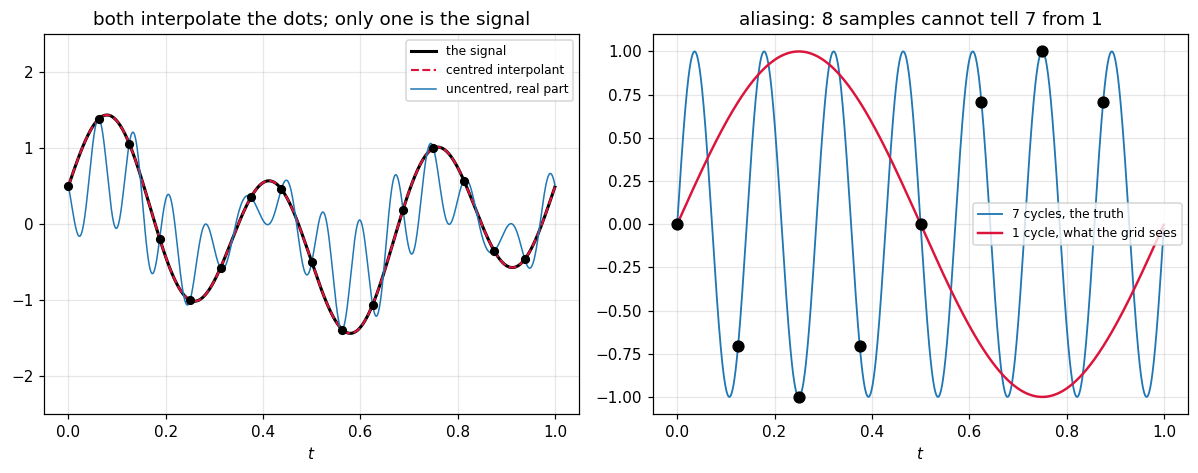

In [15]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

n_pic = 16
grid = np.arange(n_pic) / n_pic
data = np.sin(2.0 * np.pi * 3.0 * grid) + 0.5 * np.cos(2.0 * np.pi * grid)
X = dt.dft(data)
fine = np.linspace(0.0, 1.0, 1600, endpoint=False)
ax_left.plot(fine, np.sin(2 * np.pi * 3 * fine) + 0.5 * np.cos(2 * np.pi * fine),
             "k-", lw=2.0, label="the signal")
ax_left.plot(fine, np.real(dt.centred_interpolant(X, fine)), color="crimson", lw=1.4,
             ls="--", label="centred interpolant")
ax_left.plot(fine, np.real(dt.trig_interpolant(X, fine)), color="tab:blue", lw=1.0,
             label="uncentred, real part")
ax_left.plot(grid, data, "ko", ms=5)
ax_left.set_ylim(-2.5, 2.5)
ax_left.set_title("both interpolate the dots; only one is the signal")
ax_left.set_xlabel("$t$")
ax_left.legend(fontsize=8)

n_alias = 8
coarse = np.arange(n_alias) / n_alias
ax_right.plot(fine, np.sin(2 * np.pi * 7 * fine), color="tab:blue", lw=1.2,
              label="7 cycles, the truth")
ax_right.plot(fine, np.sin(2 * np.pi * 1 * fine), color="crimson", lw=1.6,
              label="1 cycle, what the grid sees")
ax_right.plot(coarse, np.sin(2 * np.pi * 7 * coarse), "ko", ms=7)
ax_right.set_title(f"aliasing: {n_alias} samples cannot tell 7 from 1")
ax_right.set_xlabel("$t$")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is section 4: both curves pass through all sixteen dots and only the centred one
is the function they came from. The right panel is section 5: the two sine waves agree at every
sample and disagree everywhere else, and no algorithm can recover which one was measured.

## 9. Exercises

**Level 1, conceptual**

1.1 The DFT matrix has condition number exactly 1 while the Vandermonde matrix on the same nodes
reaches $10^{16}$. Both are interpolation matrices. Say what the DFT has that the Vandermonde does
not, in one sentence, and what it costs.

1.2 Aliasing is described as worse than interpolation error. Say precisely what the difference is
and why no better algorithm helps.

1.3 The uncentred interpolant reproduces the data exactly and is still the wrong answer. Say what
"wrong" means here, given that it interpolates.

**Level 2, mathematical**

2.1 Prove $F^HF = nI$, and identify where $w^n = 1$ is used.

2.2 Prove the DFT interpolation theorem directly from the inverse transform.

2.3 Prove the Hermitian symmetry $X_{n-k} = \overline{X_k}$ for real input, and count the
independent real numbers for $n$ even and $n$ odd.

2.4 Prove the shift theorem, and deduce that the magnitude spectrum is invariant under any
circular shift.

2.5 Prove the convolution theorem, and say exactly why the convolution it gives is **circular**
rather than linear.

**Level 3, computational**

3.1 Implement **zero padding** and show that it interpolates the spectrum rather than adding
information, by comparing against the exact continuous transform.

3.2 Implement the **Goertzel algorithm**, which computes a single DFT bin in $O(n)$ without a
transform, and say when it beats an FFT.

3.3 Implement **linear convolution from circular convolution** by padding to length
$n_1 + n_2 - 1$, and verify it against a direct sum.

**Level 4, experimental**

4.1 Measure the reconstruction error against the sampling rate for a tone sweeping through the
Nyquist limit, and confirm the folding formula.

4.2 Measure the growth of the naive twiddle recurrence's error against $n$, fit the exponent, and
confirm it is linear.

4.3 Measure the accuracy of the DFT of a signal with a very large dynamic range, and find where
the small components are lost.

**Level 5, advanced**

5.1 **Why zero padding does not add resolution.** It makes the spectrum look smoother. Say
precisely what it computes and what would be needed to genuinely resolve two nearby frequencies.

5.2 **Leakage and windowing.** A tone whose frequency is not an exact bin spreads across all
bins. Explain why, in terms of the periodic extension, and say what a window function trades
away to reduce it.

5.3 **The DFT as an eigendecomposition.** The circulant matrices are exactly the matrices
diagonalised by $F$. State that precisely, and connect it to Part 6's eigenvalue problem and to
Part 4's Krylov methods on circulant preconditioners.

## 10. Key takeaways

- **On an equally spaced grid the trigonometric basis is orthogonal exactly**, with no integrals
  and no quadrature. That is what the whole subject is built on.

- **The DFT matrix has condition number exactly 1** at every size, where the Vandermonde matrix on
  the same nodes reaches $1.9\times10^{16}$ by 20 nodes.

- **The DFT coefficients are the coefficients of the interpolating trigonometric polynomial**, so
  interpolation costs one transform and no linear system.

- **Get the frequency convention right.** Both conventions interpolate the data exactly; the
  uncentred one is off by 1.43 between the points on a signal bounded by 1.5, and complex.

- **Aliasing removes information rather than approximating it.** Frequencies $n$ apart give
  identical samples, so a 7 cycle tone sampled 8 times is reported as 1 cycle and nothing in the
  data reveals it.

- **Convolution becomes multiplication**, which is worth nothing until the transform is fast and
  is worth a great deal once it is.

- **Generate twiddle factors by the increment recurrence.** The naive one drifts linearly in $n$,
  reaching a factor of 143 worse at $n = 16384$, because its modulus wanders off 1.

## Where this goes next

Lesson 59 makes the transform $O(n\log n)$, which turns every result here from a definition into
a tool, and then uses it for fitting and filtering. Lesson 60 changes the boundary condition from
periodic to reflected, which fixes the one thing the DFT is bad at and produces the transform
inside every image and audio codec.